# Practical 01: Simple Linear Regression

In [19]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression


## Load Dataset

In [20]:

iris = load_iris()
X = iris.data[:50, 0]
Y = iris.data[:50, 1]


## Method 1: Covariance (Statistical) Method

In [21]:

x_mean = np.mean(X)
y_mean = np.mean(Y)

cov_xy = np.mean((X - x_mean) * (Y - y_mean))
var_x = np.mean((X - x_mean) ** 2)

m1 = cov_xy / var_x
c1 = y_mean - m1 * x_mean

print("Statistical Method")
print("Slope:", m1)
print("Intercept:", c1)


Statistical Method
Slope: 0.7985283006471532
Intercept: -0.5694326730396493


## Method 2: Normal Equation (Matrix Method)

In [22]:

X_matrix = X.reshape(-1, 1)
Y_matrix = Y.reshape(-1, 1)

X_design = np.hstack((np.ones((X_matrix.shape[0], 1)), X_matrix))

theta = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ Y_matrix

c2 = theta[0][0]
m2 = theta[1][0]

print("Matrix Method")
print("Slope:", m2)
print("Intercept:", c2)


Matrix Method
Slope: 0.7985283006471879
Intercept: -0.5694326730399227


## Method 3: Gradient Descent Method

In [23]:

m = 0
c = 0
learning_rate = 0.01
epochs = 1000
n = len(X)

for i in range(epochs):
    y_pred = m * X + c
    dm = (-2/n) * np.sum(X * (Y - y_pred))
    dc = (-2/n) * np.sum(Y - y_pred)

    m = m - learning_rate * dm
    c = c - learning_rate * dc

print("Gradient Descent Method")
print("Slope:", m)
print("Intercept:", c)


Gradient Descent Method
Slope: 0.6716186415698543
Intercept: 0.06884605805400948


## Method 4: sklearn LinearRegression

In [24]:

model = LinearRegression()
model.fit(X_matrix, Y)

m4 = model.coef_[0]
c4 = model.intercept_

print("Sklearn Method")
print("Slope:", m4)
print("Intercept:", c4)


Sklearn Method
Slope: 0.798528300647153
Intercept: -0.569432673039648


## Visualization

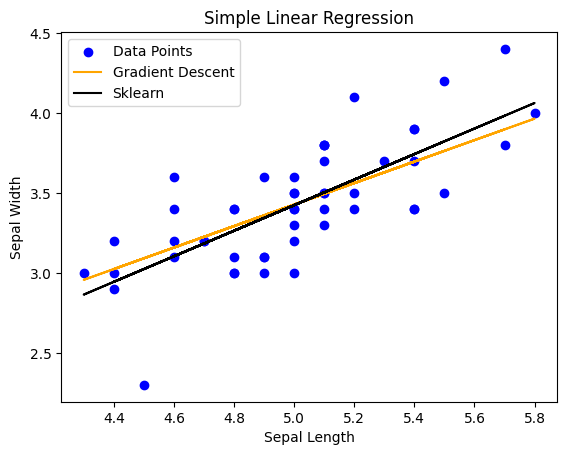

In [25]:

plt.scatter(X, Y, color='blue', label='Data Points')
plt.plot(X, m*X + c, color='orange', label='Gradient Descent')
plt.plot(X, m4*X + c4, color='black', label='Sklearn')

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()
